# Notebook 1: Exploratory Data Analysis (EDA)
**Customer Churn & Revenue Risk Analytics Platform**

**Goal:** Understand the structure of the Telco dataset, identify patterns in churned vs. retained customers, and surface business insights that will guide feature engineering and modeling.

**Key questions we'll answer:**
1. What is the overall churn rate?
2. Which customer segments churn most?
3. How do billing and tenure relate to churn?
4. What features are most correlated with churn?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load & Inspect the Data

In [3]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Basic descriptive statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Fix known data quality issue: TotalCharges is stored as string
# New customers (tenure=0) have a blank string instead of 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

n_missing = df['TotalCharges'].isna().sum()
print(f'TotalCharges NaN values after coercion: {n_missing}')
print('These are new customers with tenure = 0:')
print(df[df['TotalCharges'].isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

# Fill with MonthlyCharges (they've only been charged once)
df.loc[df['TotalCharges'].isna(), 'TotalCharges'] = df.loc[df['TotalCharges'].isna(), 'MonthlyCharges']
print(f'\nFixed. Remaining NaN values: {df["TotalCharges"].isna().sum()}')

TotalCharges NaN values after coercion: 11
These are new customers with tenure = 0:
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN

Fixed. Remaining NaN values: 0


In [7]:
# Encode target variable
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

churn_rate = df['Churn_Binary'].mean()
print(f'Overall churn rate: {churn_rate:.1%}')
print(f'Churned customers:  {df["Churn_Binary"].sum():,}')
print(f'Retained customers: {(df["Churn_Binary"] == 0).sum():,}')

Overall churn rate: 26.5%
Churned customers:  1,869
Retained customers: 5,174


## 2. Target Variable Distribution

**Insight to look for:** Class imbalance. If churn rate is ~27%, a naive model that always predicts 'No Churn' would be 73% accurate — which is why we can't use accuracy as our primary metric.

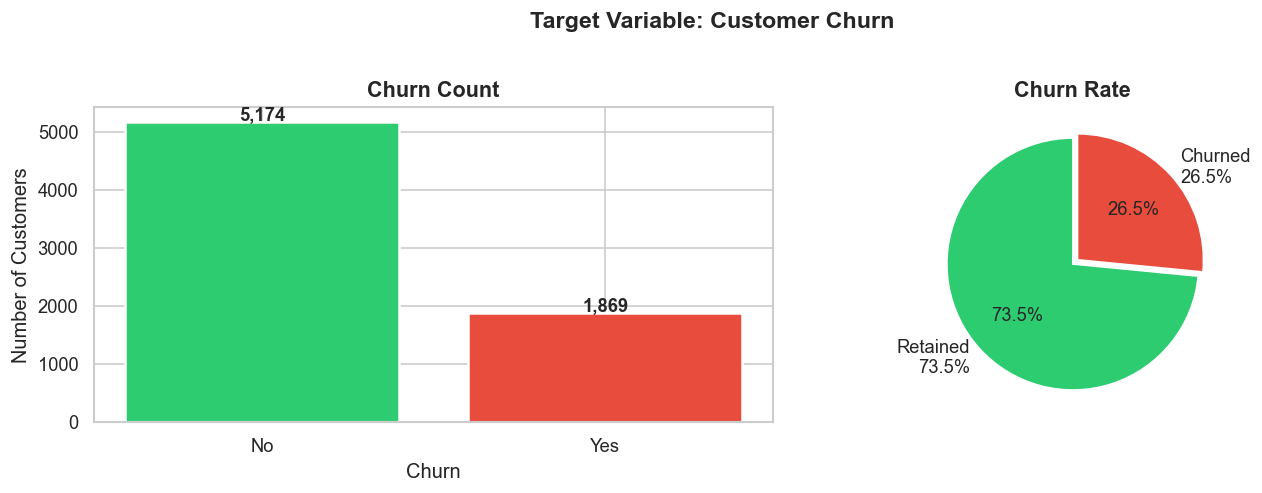

Key insight: ~26.5% churn rate — class imbalance means accuracy is a misleading metric.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['Churn'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    counts.values,
    labels=[f'Retained\n{counts["No"]/len(df):.1%}', f'Churned\n{counts["Yes"]/len(df):.1%}'],
    colors=['#2ecc71', '#e74c3c'],
    explode=[0, 0.05],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Churn Rate', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Customer Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/01_churn_distribution.png', bbox_inches='tight')
plt.show()
print('Key insight: ~26.5% churn rate — class imbalance means accuracy is a misleading metric.')

## 3. Churn by Contract Type

**Hypothesis:** Month-to-month customers have lower switching costs and higher churn.

      Contract  Churn Rate  Count  Churn Rate %
Month-to-month    0.427097   3875          42.7
      One year    0.112695   1473          11.3
      Two year    0.028319   1695           2.8


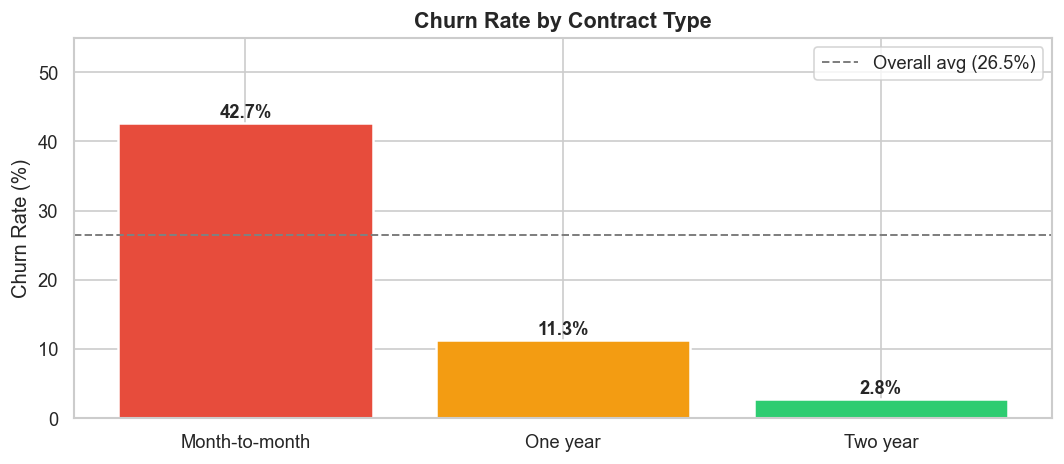

Key insight: Month-to-month customers churn at ~42% vs ~11% (one year) and ~3% (two year).


In [9]:
contract_churn = df.groupby('Contract')['Churn_Binary'].agg(['mean', 'count']).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate', 'Count']
contract_churn['Churn Rate %'] = (contract_churn['Churn Rate'] * 100).round(1)
contract_churn = contract_churn.sort_values('Churn Rate', ascending=False)

print(contract_churn.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    contract_churn['Contract'],
    contract_churn['Churn Rate %'],
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='white', linewidth=1.5
)
ax.axhline(y=churn_rate * 100, color='gray', linestyle='--', linewidth=1.2, label=f'Overall avg ({churn_rate:.1%})')
ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
ax.legend()
for bar, val in zip(bars, contract_churn['Churn Rate %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8, f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/02_churn_by_contract.png', bbox_inches='tight')
plt.show()
print('Key insight: Month-to-month customers churn at ~42% vs ~11% (one year) and ~3% (two year).')

## 4. Tenure Distribution by Churn Status

**Hypothesis:** New customers are more likely to churn — they haven't yet experienced full value.

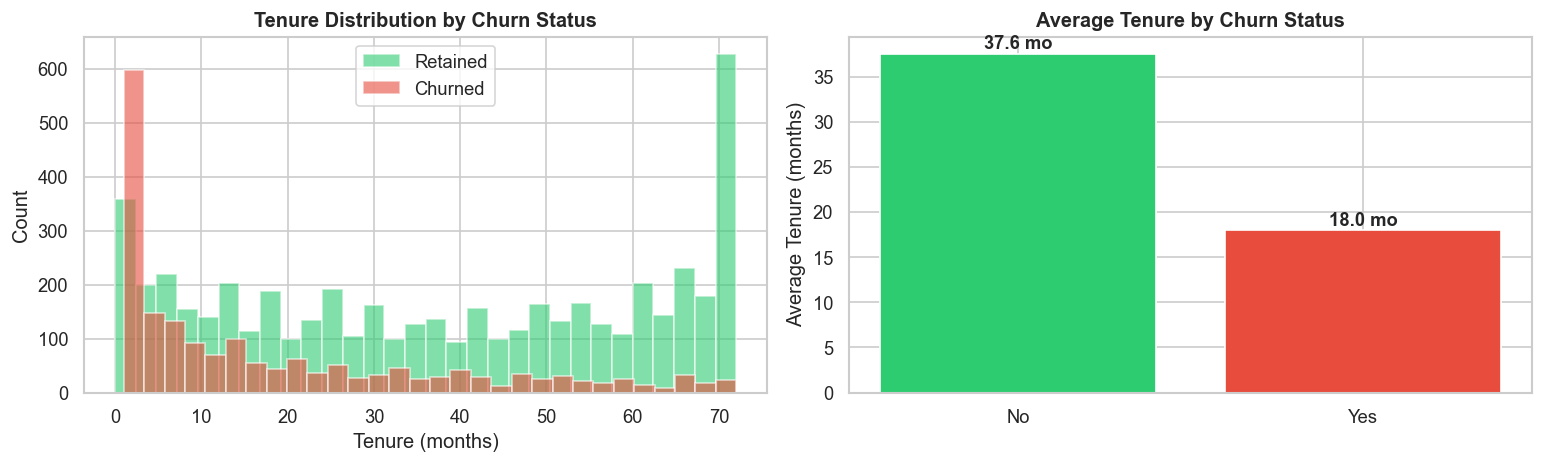

Avg tenure (retained): 37.6 months
Avg tenure (churned):  18.0 months
Key insight: Churned customers have ~half the tenure of retained customers.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of tenure by churn group
for label, color, group in [('Retained', '#2ecc71', df[df['Churn_Binary']==0]),
                              ('Churned',  '#e74c3c', df[df['Churn_Binary']==1])]:
    axes[0].hist(group['tenure'], bins=30, alpha=0.6, color=color, label=label, edgecolor='white')

axes[0].set_title('Tenure Distribution by Churn Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Average tenure by churn
avg_tenure = df.groupby('Churn')['tenure'].mean()
axes[1].bar(avg_tenure.index, avg_tenure.values, color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title('Average Tenure by Churn Status', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Tenure (months)')
for i, v in enumerate(avg_tenure.values):
    axes[1].text(i, v + 0.5, f'{v:.1f} mo', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/03_tenure_vs_churn.png', bbox_inches='tight')
plt.show()

print(f'Avg tenure (retained): {df[df["Churn_Binary"]==0]["tenure"].mean():.1f} months')
print(f'Avg tenure (churned):  {df[df["Churn_Binary"]==1]["tenure"].mean():.1f} months')
print('Key insight: Churned customers have ~half the tenure of retained customers.')

## 5. Monthly Charges vs Churn

**Hypothesis:** Higher charges = higher churn risk (price sensitivity).

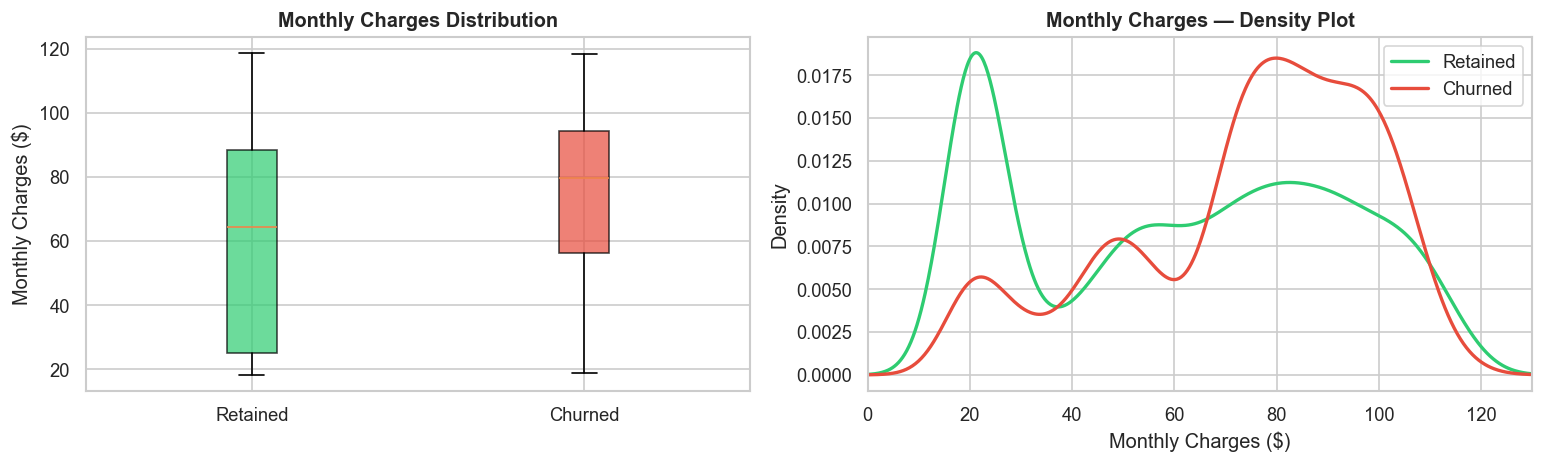

Avg monthly charges (retained): $61.27
Avg monthly charges (churned):  $74.44
Key insight: Churned customers pay significantly more per month on average.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plot
churn_groups = [df[df['Churn']=='No']['MonthlyCharges'], df[df['Churn']=='Yes']['MonthlyCharges']]
bp = axes[0].boxplot(churn_groups, labels=['Retained', 'Churned'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
for patch in bp['boxes']:
    patch.set_alpha(0.7)
axes[0].set_title('Monthly Charges Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Monthly Charges ($)')

# KDE plot
for label, color, group in [('Retained', '#2ecc71', df[df['Churn_Binary']==0]),
                              ('Churned',  '#e74c3c', df[df['Churn_Binary']==1])]:
    group['MonthlyCharges'].plot.kde(ax=axes[1], color=color, label=label, linewidth=2)

axes[1].set_title('Monthly Charges — Density Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].legend()
axes[1].set_xlim(0, 130)

plt.tight_layout()
plt.savefig('../reports/figures/04_monthly_charges_vs_churn.png', bbox_inches='tight')
plt.show()

print(f'Avg monthly charges (retained): ${df[df["Churn_Binary"]==0]["MonthlyCharges"].mean():.2f}')
print(f'Avg monthly charges (churned):  ${df[df["Churn_Binary"]==1]["MonthlyCharges"].mean():.2f}')
print('Key insight: Churned customers pay significantly more per month on average.')

## 6. Churn by Internet Service Type

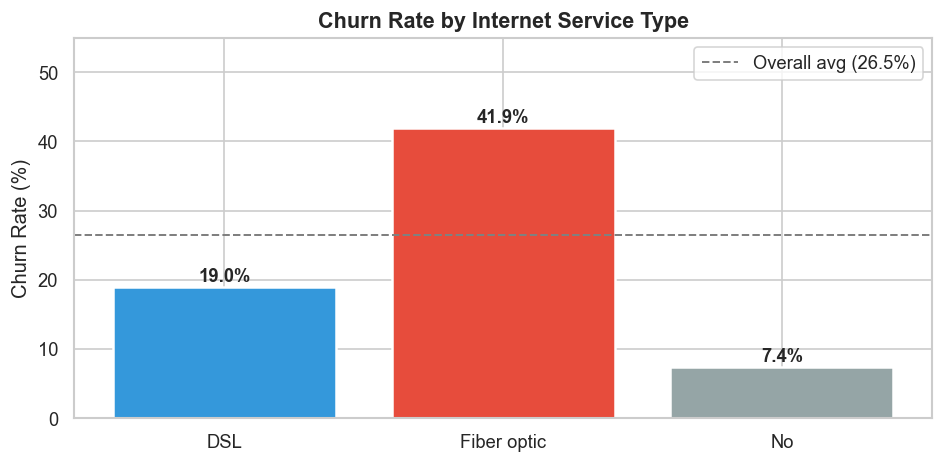

Key insight: Fiber optic customers churn at ~42% — possibly due to higher prices or competition.


In [12]:
internet_churn = df.groupby('InternetService')['Churn_Binary'].agg(['mean', 'count']).reset_index()
internet_churn.columns = ['InternetService', 'Churn Rate', 'Count']
internet_churn['Churn Rate %'] = (internet_churn['Churn Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    internet_churn['InternetService'],
    internet_churn['Churn Rate %'],
    color=['#3498db', '#e74c3c', '#95a5a6'],
    edgecolor='white', linewidth=1.5
)
ax.axhline(y=churn_rate * 100, color='gray', linestyle='--', linewidth=1.2, label=f'Overall avg ({churn_rate:.1%})')
ax.set_title('Churn Rate by Internet Service Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
ax.legend()
for bar, val in zip(bars, internet_churn['Churn Rate %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8, f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/05_churn_by_internet.png', bbox_inches='tight')
plt.show()
print('Key insight: Fiber optic customers churn at ~42% — possibly due to higher prices or competition.')

## 7. Churn Rates Across All Categorical Features

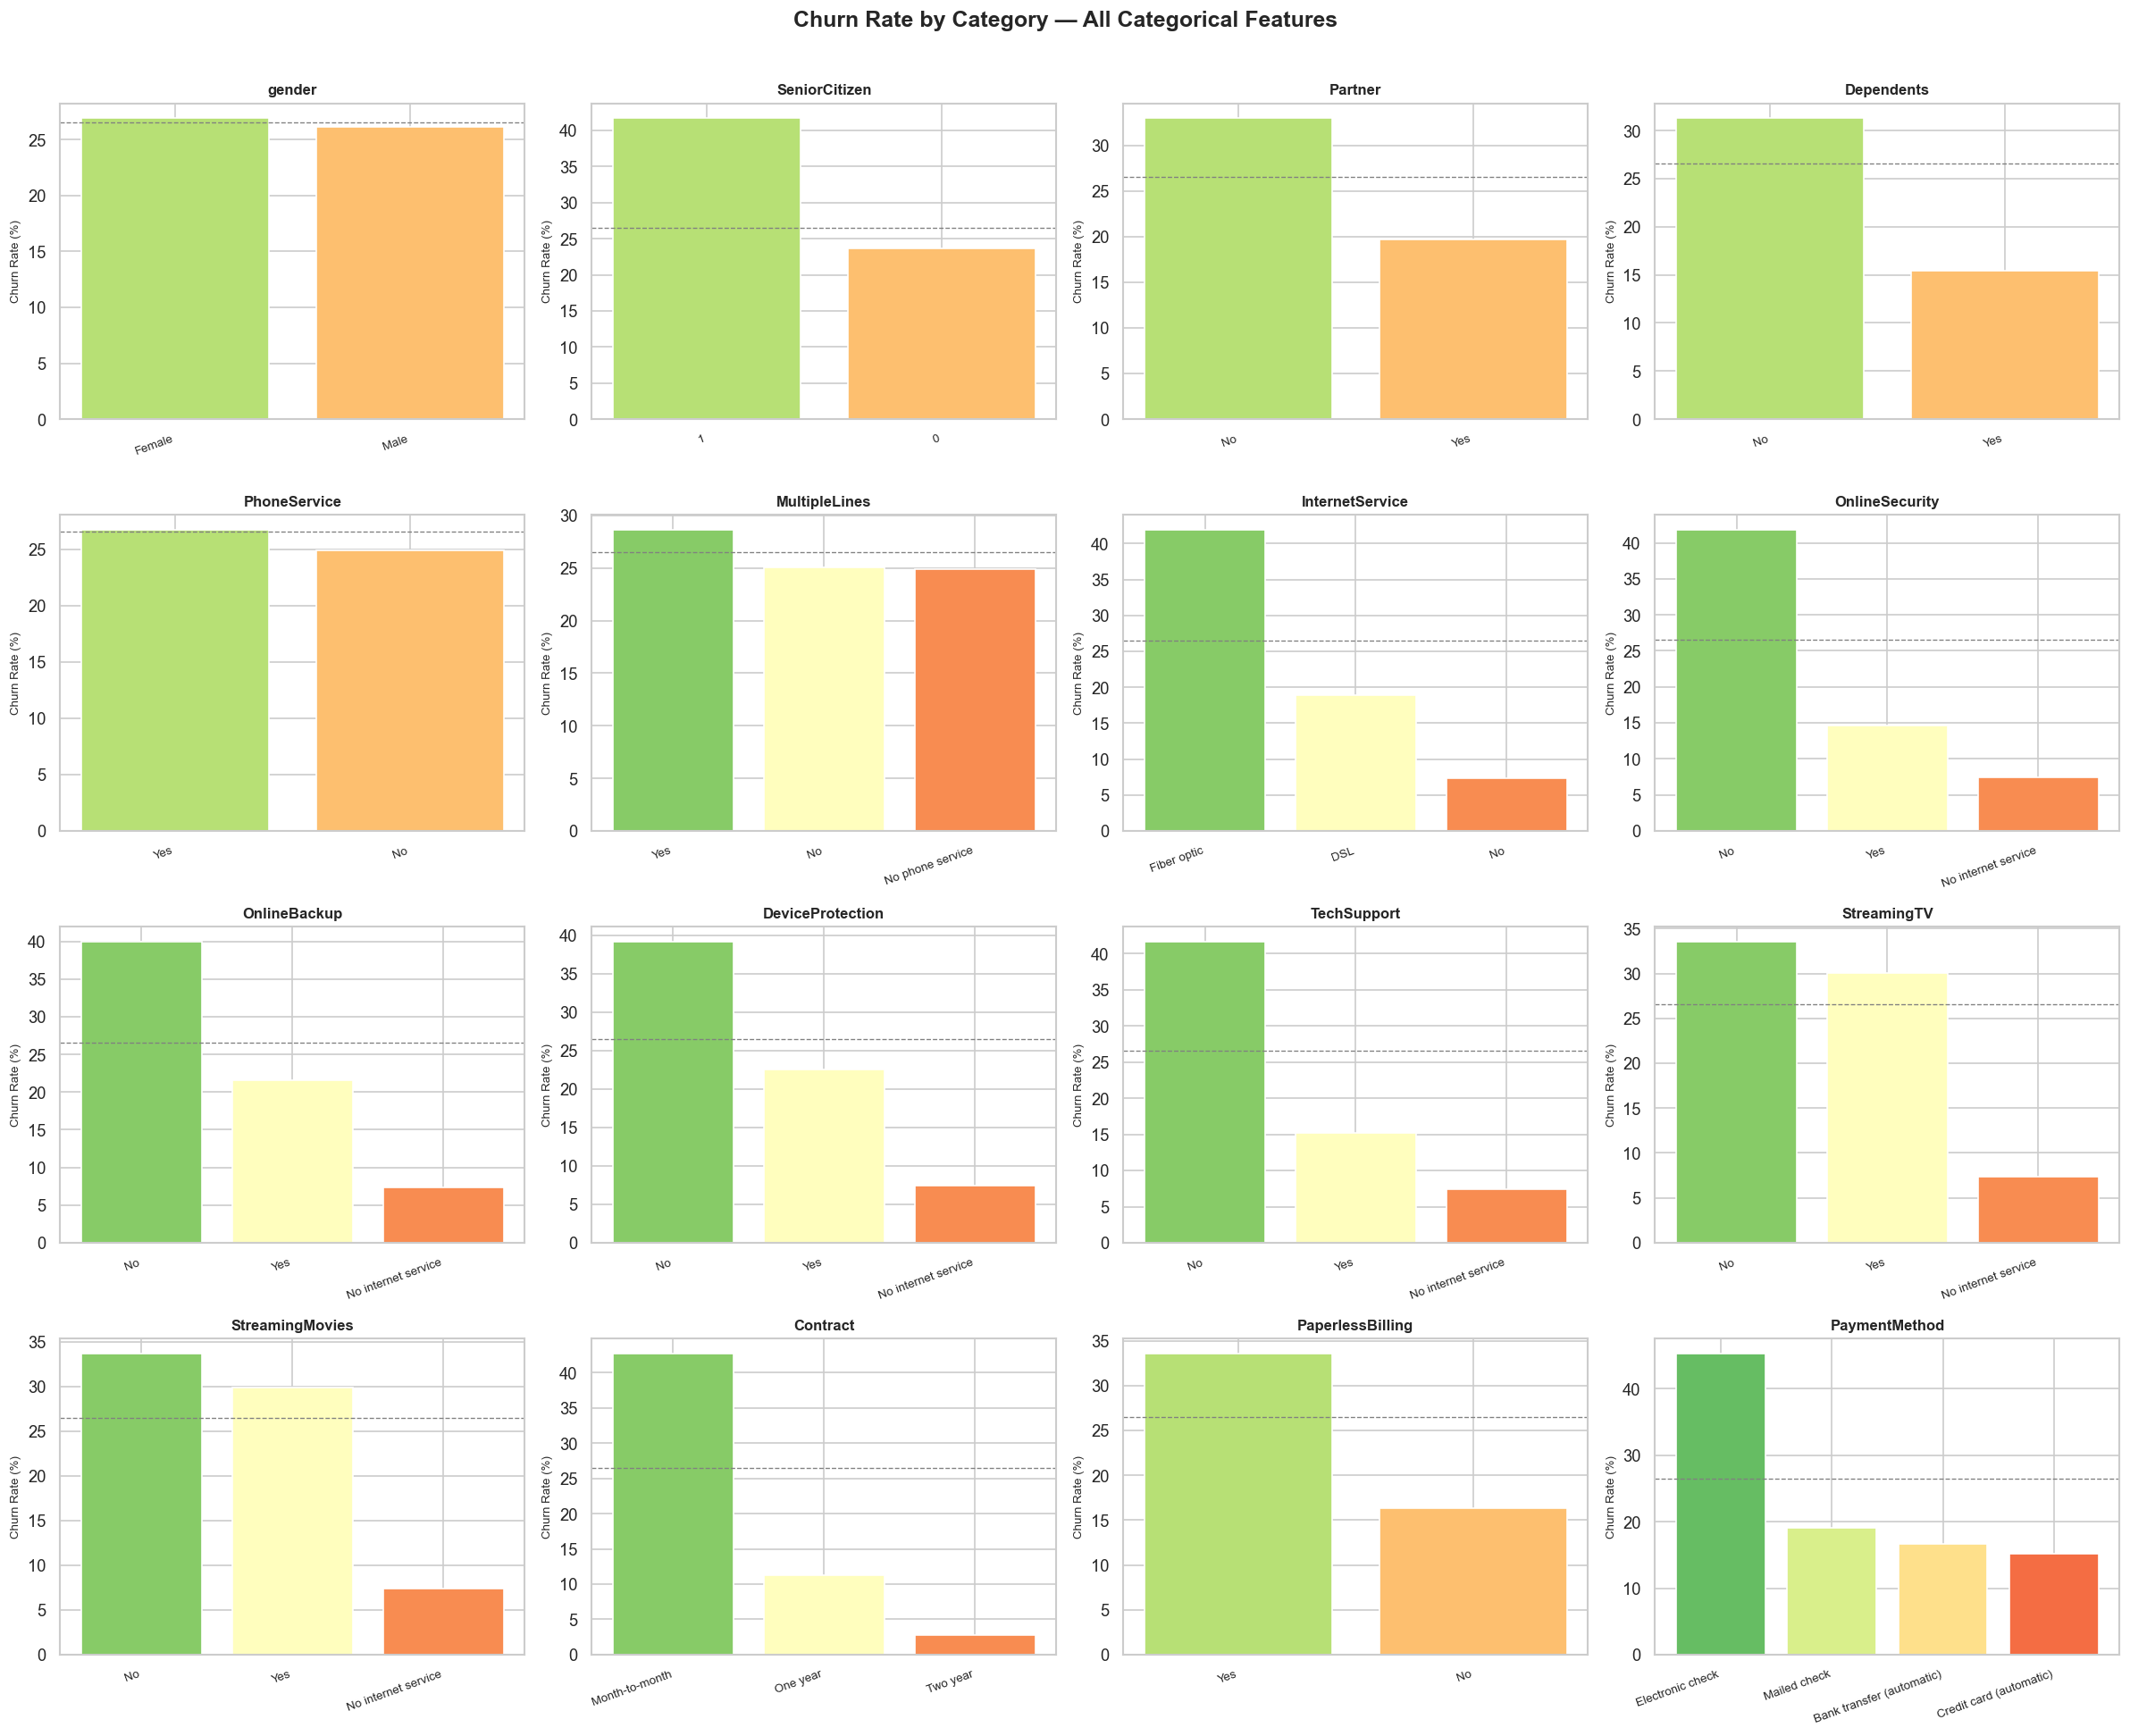

In [13]:
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_by_cat = df.groupby(col)['Churn_Binary'].mean().sort_values(ascending=False)
    axes[i].bar(range(len(churn_by_cat)), churn_by_cat.values * 100,
                color=sns.color_palette('RdYlGn_r', len(churn_by_cat)))
    axes[i].set_xticks(range(len(churn_by_cat)))
    axes[i].set_xticklabels(churn_by_cat.index, rotation=20, ha='right', fontsize=8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)', fontsize=8)
    axes[i].axhline(y=churn_rate * 100, color='gray', linestyle='--', linewidth=0.8)

# Hide unused subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Category — All Categorical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/06_churn_all_categoricals.png', bbox_inches='tight')
plt.show()

## 8. Correlation Heatmap (Numerical Features)

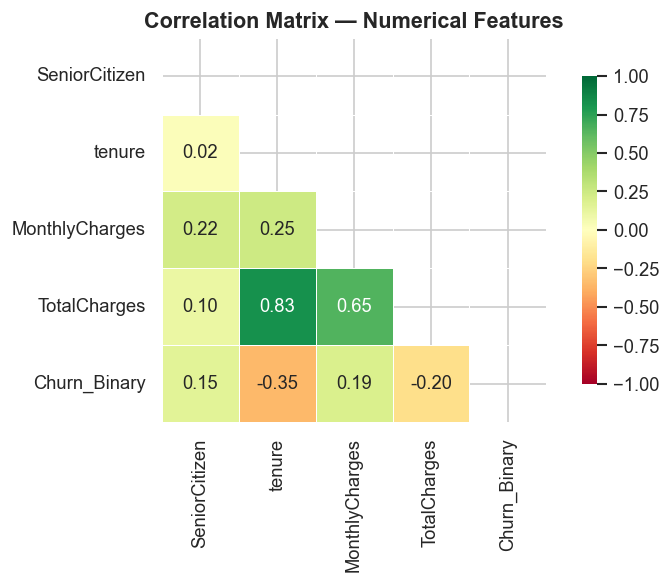

Key insight: tenure has the strongest negative correlation with churn (-0.35).
MonthlyCharges has a positive correlation — higher bills, more churn.


In [14]:
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/07_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Key insight: tenure has the strongest negative correlation with churn (-0.35).')
print('MonthlyCharges has a positive correlation — higher bills, more churn.')

## 9. Revenue Risk Preview — CLV vs Churn Probability (manual estimate)

Total CLV lost to churn:        $2,862,577
Average CLV per churned customer: $1,532
Number of churned customers:      1,869


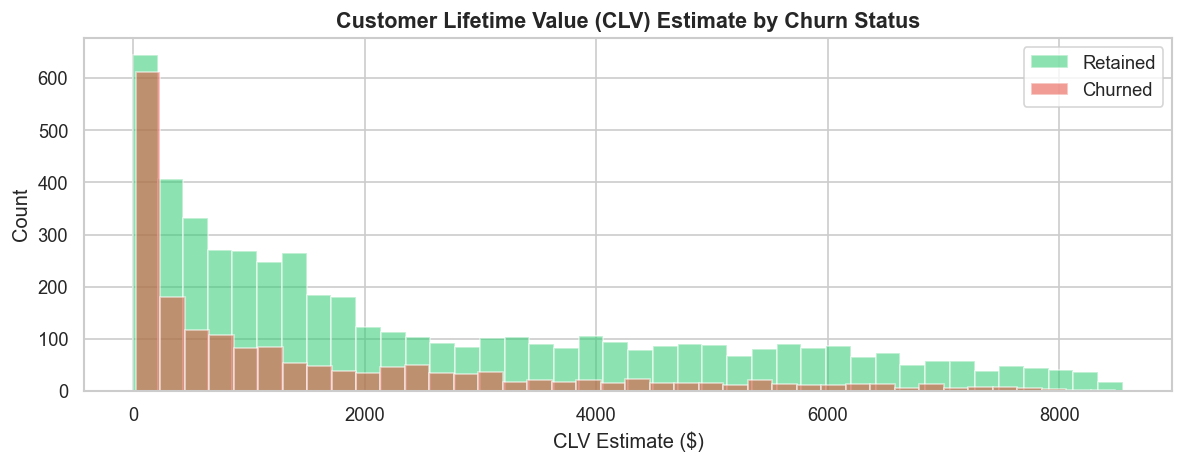

In [15]:
# Simple CLV estimate: MonthlyCharges × tenure
df['clv_estimate'] = df['MonthlyCharges'] * df['tenure']

# Revenue at risk from actual churned customers
actual_churned = df[df['Churn_Binary'] == 1]
total_clv_at_risk = actual_churned['clv_estimate'].sum()
avg_clv_churned = actual_churned['clv_estimate'].mean()

print(f'Total CLV lost to churn:        ${total_clv_at_risk:,.0f}')
print(f'Average CLV per churned customer: ${avg_clv_churned:,.0f}')
print(f'Number of churned customers:      {len(actual_churned):,}')

# CLV distribution by churn
fig, ax = plt.subplots(figsize=(10, 4))
for label, color, group in [('Retained', '#2ecc71', df[df['Churn_Binary']==0]),
                              ('Churned',  '#e74c3c', df[df['Churn_Binary']==1])]:
    ax.hist(group['clv_estimate'], bins=40, alpha=0.55, color=color, label=label, edgecolor='white')

ax.set_title('Customer Lifetime Value (CLV) Estimate by Churn Status', fontsize=13, fontweight='bold')
ax.set_xlabel('CLV Estimate ($)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/08_clv_distribution.png', bbox_inches='tight')
plt.show()

## 10. EDA Summary — Key Findings

| Finding | Detail |
|---|---|
| Overall churn rate | ~26.5% — class imbalance requires AUC-ROC, not accuracy |
| Contract type | Month-to-month: 42% churn vs 3% for two-year contracts |
| Tenure | Churned customers average ~18 months vs ~38 months for retained |
| Monthly charges | Churned customers pay ~$74/mo vs ~$61/mo for retained |
| Internet service | Fiber optic customers churn at ~42% — highest risk segment |
| CLV at risk | Significant revenue lost from churned customers with long tenure |

**These findings directly inform our feature engineering strategy in Notebook 2.**

In [16]:
# Save cleaned DataFrame for use in next notebook
df.to_csv('../data/processed/telco_cleaned.csv', index=False)
print('Saved: data/processed/telco_cleaned.csv')
print(f'Shape: {df.shape}')
print('Ready for Notebook 2: Feature Engineering')

Saved: data/processed/telco_cleaned.csv
Shape: (7043, 23)
Ready for Notebook 2: Feature Engineering
